<a href="https://colab.research.google.com/github/paulinepiccio/cinema-and-war/blob/main/notebooks/04_analysis_and_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Clean plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 13

# Load the classified dataset
DATA_URL = "https://raw.githubusercontent.com/paulinepiccio/cinema-and-war/main/data/processed/war_movies_classified.csv"
CONFLICTS_URL = "https://raw.githubusercontent.com/paulinepiccio/cinema-and-war/refs/heads/main/data/conflits.csv"

df = pd.read_csv(DATA_URL)
conflicts = pd.read_csv(CONFLICTS_URL)

# Focus on classified films
df_classified = df[df['matched_conflict'].notna()].copy()

print(f"Total films loaded: {df.shape[0]}")
print(f"Classified films: {df_classified.shape[0]}")
print(f"Unique conflicts: {df_classified['matched_conflict'].nunique()}")

print(f"\nClassified films per country:")
print(df_classified['primary_country'].value_counts())

Total films loaded: 2343
Classified films: 1445
Unique conflicts: 26

Classified films per country:
primary_country
US    649
GB    254
RU    208
FR    167
DE    105
JP     62
Name: count, dtype: int64


How many classified war films does each country contribute to the dataset?
This gives us our **first baseline** for comparison.

/tmp/ipykernel_15888/3203872231.py:48: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15888/3203872231.py:48: UserWarning: Glyph 127480 (\N{REGIONAL INDICATOR SYMBOL LETTER S}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15888/3203872231.py:48: UserWarning: Glyph 127468 (\N{REGIONAL INDICATOR SYMBOL LETTER G}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15888/3203872231.py:48: UserWarning: Glyph 127463 (\N{REGIONAL INDICATOR SYMBOL LETTER B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15888/3203872231.py:48: UserWarning: Glyph 127479 (\N{REGIONAL INDICATOR SYMBOL LETTER R}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15888/3203872231.py:48: UserWarning: Glyph 127467 (\N{REGIONAL INDICATOR SYMBOL LETTER F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15888/3203872231.py

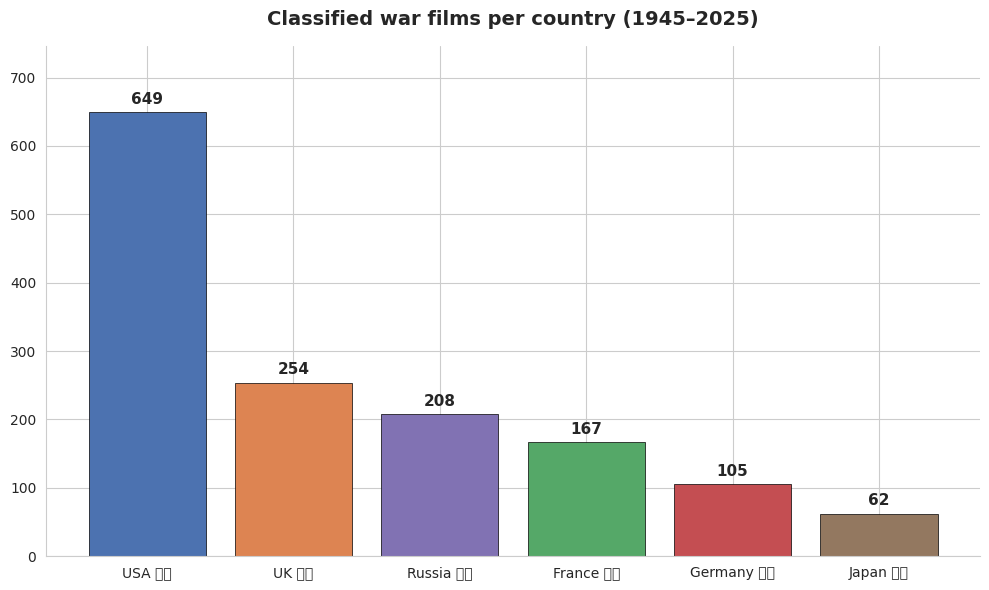


Country share of classified films:
   USA 🇺🇸: 649 films (44.9%)
   UK 🇬🇧: 254 films (17.6%)
   Russia 🇷🇺: 208 films (14.4%)
   France 🇫🇷: 167 films (11.6%)
   Germany 🇩🇪: 105 films (7.3%)
   Japan 🇯🇵: 62 films (4.3%)


In [2]:
# Volume of classified war films per country
country_counts = df_classified['primary_country'].value_counts()

# Map country codes to readable names for display
COUNTRY_NAMES = {
    'US': 'USA 🇺🇸',
    'GB': 'UK 🇬🇧',
    'FR': 'France 🇫🇷',
    'DE': 'Germany 🇩🇪',
    'RU': 'Russia 🇷🇺',
    'JP': 'Japan 🇯🇵'
}

# Distinct categorical colors (Seaborn-inspired palette)
COUNTRY_COLORS = {
    'US': '#4C72B0',  # blue
    'GB': '#DD8452',  # orange
    'FR': '#55A868',  # green
    'DE': '#C44E52',  # red
    'RU': '#8172B3',  # purple
    'JP': '#937860',  # brown
}

# Build the bar chart
fig, ax = plt.subplots(figsize=(10, 6))

countries = country_counts.index.tolist()
values = country_counts.values
labels = [COUNTRY_NAMES.get(c, c) for c in countries]
colors = [COUNTRY_COLORS.get(c, '#999') for c in countries]

bars = ax.bar(labels, values, color=colors, edgecolor='black', linewidth=0.5)

# Add value labels on top of each bar
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 8,
            f'{value}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Classified war films per country (1945–2025)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, max(values) * 1.15)

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Print percentages
total = country_counts.sum()
print("\nCountry share of classified films:")
for country, count in country_counts.items():
    pct = count / total * 100
    print(f"   {COUNTRY_NAMES.get(country, country)}: {count} films ({pct:.1f}%)")

### Key insights

- **USA dominates** with 649 classified films (~45% of the dataset),
  reflecting Hollywood's massive war cinema output across all decades.

- **The UK** is the second-largest contributor (254 films, 18%),
  with a 2.5x gap from the USA, consistent with its smaller but
  globally influential film industry.

- **Russia/USSR ranks third** (208 films, 14%), driven by the rich
  Soviet tradition of war cinema (1945-1991) and contemporary Russian
  productions on conflicts like Chechnya and Ukraine. Films originally
  tagged as Soviet Union (SU) on TMDB have been merged into the Russia
  category for analytical continuity, with the original era preserved
  in a dedicated 'era' column.

- **France** (167 films, 12%) and **Germany** (105 films, 7%) reflect
  smaller domestic industries but each with distinctive thematic
  signatures (French colonial conflicts, German engagement with WWII memory).

- **Japan** is the smallest contributor (62 films, 4%), consistent
  with its post-1947 pacifist constitution and the absence
  of direct military involvement in most conflicts of this period.

 **Caveat**: this absolute volume is not directly comparable across
countries. It reflects industry size, TMDB metadata coverage, and
audience reach. Subsequent analyses will use **proportions** rather
than absolute counts to enable fair comparisons.

In [3]:
import plotly.graph_objects as go

# Create a 'decade' column
df_classified['decade'] = (df_classified['release_year'] // 10 * 10).astype(int)

# Filter for decades with valid data and ensure they are within a reasonable range (1940s onwards)
df_classified_filtered = df_classified[(df_classified['decade'] >= 1940) & (df_classified['decade'] <= 2020)].copy()

# Calculate the number of films per decade per country
decade_country = df_classified_filtered.groupby(['decade', 'primary_country']).size().unstack(fill_value=0)

# Reindex to ensure all decades from 1940 to 2020 are present, filling missing with 0
all_decades = range(1940, 2030, 10)
decade_country = decade_country.reindex(all_decades, fill_value=0)

# Define country order based on existing country_counts (if available) or by columns
if 'country_counts' in locals():
    country_order = country_counts.index.tolist()
else:
    country_order = decade_country.columns.tolist()

# Ensure columns are in country_order, adding missing columns as 0 if necessary
decade_country = decade_country.reindex(columns=country_order, fill_value=0)

# Normalized version: percentage of each country's total per decade
# This allows fair comparison of TIMING regardless of country size

decade_country_pct = decade_country.div(decade_country.sum(axis=0), axis=1) * 100

# Build interactive line chart with Plotly

fig = go.Figure()

for country in country_order:
    fig.add_trace(go.Scatter(
        x=[f"{int(d)}s" for d in decade_country_pct.index],
        y=decade_country_pct[country],
        mode='lines+markers',
        name=COUNTRY_NAMES[country],
        line=dict(color=COUNTRY_COLORS[country], width=2.5),
        marker=dict(size=8),
        hovertemplate=(
            f'<b>{COUNTRY_NAMES[country]}</b><br>'
            'Decade: %{x}<br>'
            'Share: %{y:.1f}%<br>'
            '<extra></extra>'
        )
    ))

fig.update_layout(
    title=dict(
        text='Temporal distribution of war cinema (% within each country)',
        font=dict(size=15, color='black'),
        x=0.5
    ),
    xaxis_title='Decade',
    yaxis_title="% of country's total war films",
    width=1100,
    height=600,
    template='plotly_white',
    hovermode='x unified',  # show all countries' values when hovering a decade
    legend=dict(
        orientation='v',
        yanchor='top',
        y=1,
        xanchor='left',
        x=1.02
    )
)

# Add range slider at the bottom for zooming on specific periods
fig.update_xaxes(rangeslider_visible=True)

fig.show()

# Print the underlying data for reference
print("Decade share per country (% of country's total films):")
print(decade_country_pct.round(1).to_string())

Decade share per country (% of country's total films):
primary_country    US    GB    RU    FR    DE    JP
decade                                             
1940              6.2   4.3   5.8   4.2   1.0   0.0
1950             14.3  18.9   6.2   4.8  15.2  11.3
1960             11.7  12.6  21.6  15.6   9.5  14.5
1970              6.3   7.5  17.3   7.2   8.6   6.5
1980             12.9   7.5  12.0  11.4   5.7  16.1
1990              7.9   5.1   5.3  10.2   8.6   4.8
2000             12.3  14.2  10.1  13.2  14.3  14.5
2010             18.5  19.3  15.9  22.2  22.9  24.2
2020              9.9  10.6   5.8  11.4  14.3   8.1


###Key insights

**Three distinct cinematic eras emerge across most countries:**

- **The post-war boom (1950s)** is visible in 5 of 6 countries, with UK
  peaking at 18.9%, USA at 14.3%, and Germany at 15.2% of their total
  output. This reflects the massive cinematic processing of WWII memory
  in the first post-war decade.

- **A relative 1970s dip** appears in Western countries (USA 6.3%, UK 7.5%), often linked to Vietnam War fatigue and the rise of anti-establishment
  cinema.

- **The contemporary peak (2010s)** is the most striking pattern: 5 of
  6 countries reach their all-time high in this decade, ranging from
  18.5% (USA) to 24.2% (Japan). This explosion likely reflects streaming
  platforms, ongoing conflicts (Iraq, Afghanistan, Syria, Ukraine),
  and major anniversary commemorations.

**Country-specific patterns:**

- **France** shows a striking U-curve: an unusually low post-war
  output (4.2-4.8% in the 1940s-50s, the lowest among Western countries
  during this period), followed by a sharp jump in the 1960s (15.6%)
  and a steady rise to a peak of 22.2% in the 2010s. This suggests
  French cinema avoided WWII themes for decades (possibly due to
  the sensitive memory of Occupation and collaboration) before
  engaging more openly with both WWII and the Algerian War in
  subsequent decades.

- **Russia is the only country whose peak is NOT in the 2010s.**
  Russian war cinema peaks in the 1960s (21.6%) and remains strong
  through the 1970s (17.3%), corresponding to the golden age of
  Soviet WWII cinema under Khrushchev and Brezhnev. A sharp drop in
  the 1990s (5.3%) coincides with the collapse of the Soviet film
  industry, followed by a state-supported revival in the 2000s-2010s.

- **Germany** has the most volatile profile of all 6 countries
  (range 1% to 22.9%). After a strong post-war presence (15.2% in the
  1950s), output declined through the 1980s before resurging to its
  all-time high in the 2010s (22.9%). This trajectory mirrors Germany's
  evolving relationship with WWII memory, from immediate post-war
  processing, to relative silence during reconstruction, to active
  contemporary engagement.

- **Japan**'s output peaks twice (1960s and 1980s) with a notable
  hollow in the 1990s (4.8%) likely tied to Japan's economic "lost
  decade". Its 2010s share (24.2%) is the highest of any country.

- **USA and UK** share similar twin-peak profiles (1950s and
  2010s) with comparatively moderate variability. This likely reflects
  their shared anglosphere cinematic ecosystem and parallel military
  engagements (WWII, Korea, Iraq, Afghanistan).

**The big takeaway**:
> Each country's war cinema mirrors its own national history and memory
> politics. The USA and UK pulse with their military engagements
> (peaks in the 1950s and 2010s). Germany's volatile trajectory tracks
> the evolution of its WWII memory work. France's late awakening
> reflects decades of avoidance before engaging with both WWII and the
> Algerian War. Japan oscillates with its economic cycles. And Russia
> stands apart (its golden age came in the 1960s Soviet era, not in
> the contemporary streaming boom that shapes the other five countries).

Note : the 1940s decade only covers 1945–1949 (5 years), so absolute
numbers should be scaled mentally when comparing to other decades.

In [4]:
# Build a country × conflict matrix
heatmap_data = df_classified.groupby(['matched_conflict', 'primary_country']).size().unstack(fill_value=0)

# Reorder columns by our preferred country order
heatmap_data = heatmap_data.reindex(columns=country_order, fill_value=0)

# Sort conflicts by total volume (descending) — biggest at top
heatmap_data['_total'] = heatmap_data.sum(axis=1)
heatmap_data = heatmap_data.sort_values('_total', ascending=False).drop(columns='_total')

print(f"Heatmap matrix: {heatmap_data.shape[0]} conflicts × {heatmap_data.shape[1]} countries\n")
print(heatmap_data.to_string())

Heatmap matrix: 26 conflicts × 6 countries

primary_country             US   GB   RU   FR  DE  JP
matched_conflict                                     
World War II               428  213  187  134  89  59
Vietnam War                 91    6    0    7   2   1
War in Afghanistan          38    6    7    7   2   0
Iraq War                    23    5    0    1   2   0
Korean War                  27    2    0    0   0   1
Cold War                    11    3    3    1   6   0
Bosnian War                  4    3    0    4   1   1
Algerian War                 1    0    0    9   0   0
Gulf War                     8    1    0    0   1   0
First Chechen War            1    0    8    0   0   0
Russo-Ukrainian War          3    0    1    2   0   0
Syrian Civil War             2    2    0    0   1   0
Falklands War                1    4    0    0   0   0
Northern Ireland Troubles    1    3    0    0   0   0
Soviet-Afghan War            3    0    1    0   0   0
Rwandan Genocide             2    0   

/tmp/ipykernel_15888/410223968.py:28: UserWarning:

Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_15888/410223968.py:28: UserWarning:

Glyph 127480 (\N{REGIONAL INDICATOR SYMBOL LETTER S}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_15888/410223968.py:28: UserWarning:

Glyph 127468 (\N{REGIONAL INDICATOR SYMBOL LETTER G}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_15888/410223968.py:28: UserWarning:

Glyph 127463 (\N{REGIONAL INDICATOR SYMBOL LETTER B}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_15888/410223968.py:28: UserWarning:

Glyph 127479 (\N{REGIONAL INDICATOR SYMBOL LETTER R}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_15888/410223968.py:28: UserWarning:

Glyph 127467 (\N{REGIONAL INDICATOR SYMBOL LETTER F}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_15888/410223968.py:28: UserWarning:

Glyph 127465 (\N{REGIONAL INDICATOR SYMBOL LETTER D}) missing from font(s) DejaVu Sans.

/tmp/ipykerne

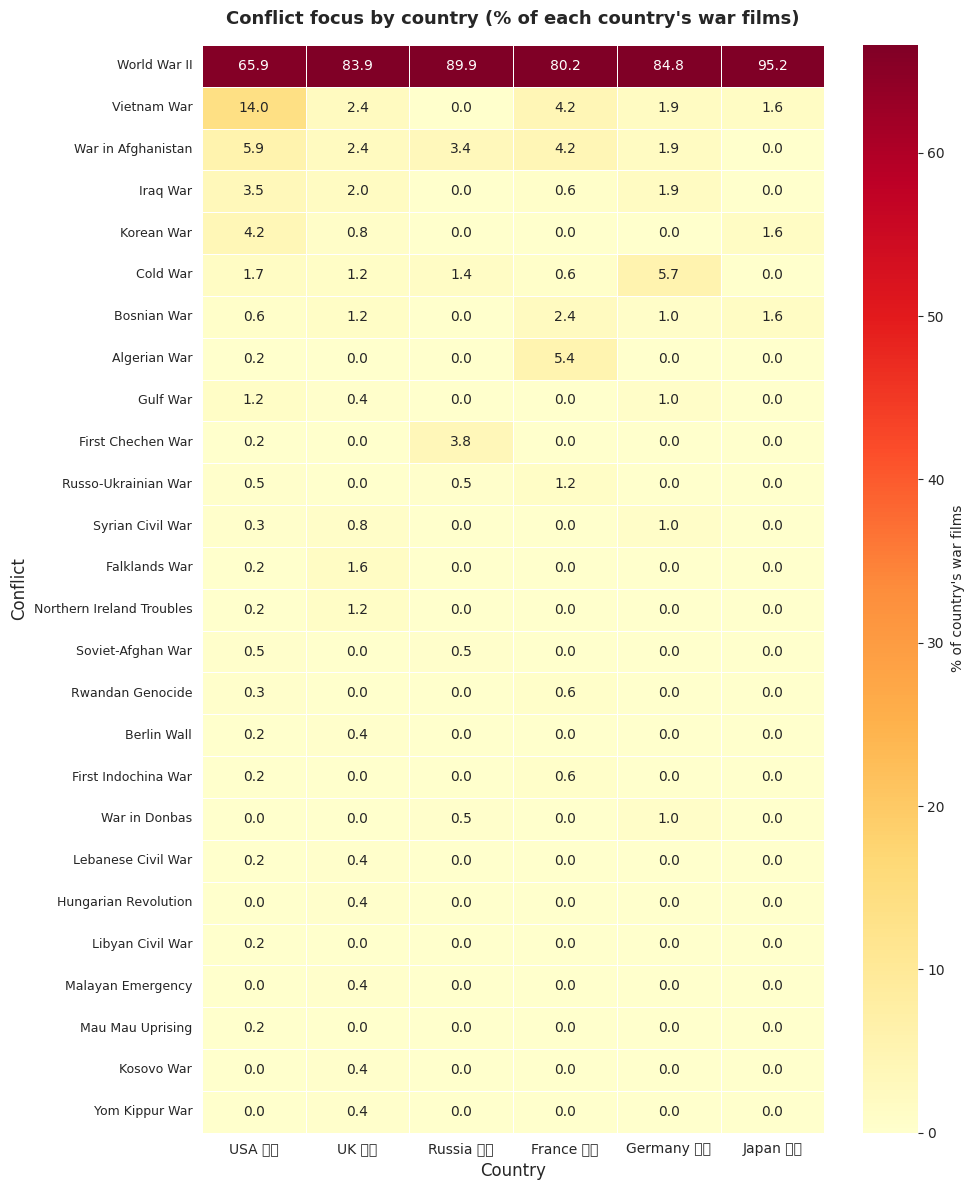

Conflict focus by country (% of each country's war films):

primary_country              US    GB    RU    FR    DE    JP
matched_conflict                                             
World War II               65.9  83.9  89.9  80.2  84.8  95.2
Vietnam War                14.0   2.4   0.0   4.2   1.9   1.6
War in Afghanistan          5.9   2.4   3.4   4.2   1.9   0.0
Iraq War                    3.5   2.0   0.0   0.6   1.9   0.0
Korean War                  4.2   0.8   0.0   0.0   0.0   1.6
Cold War                    1.7   1.2   1.4   0.6   5.7   0.0
Bosnian War                 0.6   1.2   0.0   2.4   1.0   1.6
Algerian War                0.2   0.0   0.0   5.4   0.0   0.0
Gulf War                    1.2   0.4   0.0   0.0   1.0   0.0
First Chechen War           0.2   0.0   3.8   0.0   0.0   0.0
Russo-Ukrainian War         0.5   0.0   0.5   1.2   0.0   0.0
Syrian Civil War            0.3   0.8   0.0   0.0   1.0   0.0
Falklands War               0.2   1.6   0.0   0.0   0.0   0.0
Northern I

In [5]:
# Normalize by country: each column sums to 100%
# This shows of all films a country makes, what % is about each conflict?
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=0), axis=1) * 100

fig, ax = plt.subplots(figsize=(10, 12))

sns.heatmap(
    heatmap_pct,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    cbar_kws={'label': "% of country's war films"},
    linewidths=0.5,
    linecolor='white',
    vmin=0,
    vmax=heatmap_pct.values.max() * 0.7,  # cap color scale to highlight contrasts
    ax=ax
)

ax.set_xticklabels([COUNTRY_NAMES[c] for c in heatmap_pct.columns], rotation=0, fontsize=10)
ax.set_yticklabels(heatmap_pct.index, rotation=0, fontsize=9)

ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Conflict', fontsize=12)
ax.set_title("Conflict focus by country (% of each country's war films)",
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# Print the normalized heatmap data for sharing/inspection
print("Conflict focus by country (% of each country's war films):\n")
print(heatmap_pct.round(1).to_string())

###Key insights

**WWII dominates universally, but with revealing nuances.**

- WWII accounts for 66% to 95% of each country's war cinema
- **Japan is the most mono-thematic (95.2%)**, consistent with
  Article 9 of its post-war Constitution (pacifism) and the absence
  of military involvement in most conflicts since 1945.
- **USA is the least focused on WWII (65.9%)**, the remaining
  34% spreads across Vietnam (14%), Afghanistan (5.9%), Korea (4.2%),
  Iraq (3.5%), reflecting decades of direct military engagement.

**National signatures emerge clearly:**

- **France : the Algerian War** (5.4%), a conflict no other country
  films in any significant way (USA: 0.2%, all others: 0%). French
  cinema has appropriated this difficult colonial memory almost
  exclusively.

- **Russia: the Chechen Wars** (3.8% for First Chechen War) is
  also virtually exclusive to Russian cinema. WWII (89.9%) dominates
  the rest, reflecting the centrality of the "Great Patriotic War"
  in Russian/Soviet memory.

- **Germany : the Cold War** (5.7%) is the highest share among all
  countries, reflecting Germany's unique experience of post-war division,
  the Berlin Wall, and the Stasi (films like *Goodbye Lenin!* or
  *The Lives of Others*).

- **UK : scattered colonial legacy**, small but distinctive shares
  on Falklands (1.6%), Northern Ireland (1.2%), Kosovo, Malaya, and
  the Hungarian Revolution. The British war cinema reflects an empire's
  fragmented post-colonial history.

- **USA : a war for every decade**, the only country with
  significant presence on 5+ different conflicts (Vietnam, Korea,
  Afghanistan, Iraq, Gulf War). Reflects America's role as a global
  military power.

- **Japan : the singular signature is WWII itself** with 95.2%
  of its war cinema dedicated to a single conflict, Japan's signature
  is precisely its mono-thematic focus. No other country comes close
  to this level of concentration. This unique pattern reflects two
  factors: (1) Japan's constitutional pacifism since 1947
  has limited its involvement in subsequent conflicts; (2) WWII remains
  an unfinished memory work, with films oscillating between victim
  narratives (Hiroshima, Tokyo bombings) and broader reflections on
  imperial Japan.

**Telling silences:**

- The **Mau Mau Uprising** (Kenya, 1952-60) is virtually absent from
  British cinema (0%) despite the UK's direct involvement, suggesting
  this colonial chapter remains a cinematic blind spot.

- **The Russo-Ukrainian War** (2022+) is still under-filmed across
  all countries, too recent for cinematic processing, except in
  France (1.2%) and a few American and Russian productions.

- **Korean War** is significantly filmed only by the USA (4.2%) and
  marginally by Japan (1.6%) and the UK (0.8%). France, Germany, and
  Russia have produced no films on this conflict in our dataset,
  despite Russia's (USSR) historical involvement on the North Korean
  side.

**The big takeaway:**

> War cinema is a cultural map of national memory. Each country films
> its own wars first, with WWII as the only universal reference point.  
> French cinema owns the Algerian War. Russia owns Chechnya. Germany
> processes the Cold War. The UK fragments across its colonial echoes.
> The USA spreads across every modern American war. And Japan, alone
> among the six, has condensed nearly its entire war cinema into a
> single conflict (WWII), reflecting its constitutional pacifism.

In [6]:
# Build a lookup : conflict -> set of involved country codes
conflict_countries = {}
for _, row in conflicts.iterrows():
    countries_str = row['involved_countries']
    if pd.notna(countries_str):
        country_set = set(c.strip() for c in countries_str.split(','))
        conflict_countries[row['conflict']] = country_set

# For each classified film, check if the producing country is in the conflict's involved countries
def classify_narration(row):
    conflict = row['matched_conflict']
    primary = row['primary_country']
    if conflict not in conflict_countries:
        return 'unknown'
    if primary in conflict_countries[conflict]:
        return 'self'
    else:
        return 'other'

df_classified['narration_type'] = df_classified.apply(classify_narration, axis=1)

# Overall stats
print("Overall narration breakdown:")
print(df_classified['narration_type'].value_counts())
print(f"Overall self-narration rate: {(df_classified['narration_type'] == 'self').mean()*100:.1f}%")

Overall narration breakdown:
narration_type
self     1406
other      39
Name: count, dtype: int64
Overall self-narration rate: 97.3%


/tmp/ipykernel_15888/1384891439.py:40: UserWarning:

Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_15888/1384891439.py:40: UserWarning:

Glyph 127480 (\N{REGIONAL INDICATOR SYMBOL LETTER S}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_15888/1384891439.py:40: UserWarning:

Glyph 127468 (\N{REGIONAL INDICATOR SYMBOL LETTER G}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_15888/1384891439.py:40: UserWarning:

Glyph 127463 (\N{REGIONAL INDICATOR SYMBOL LETTER B}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_15888/1384891439.py:40: UserWarning:

Glyph 127479 (\N{REGIONAL INDICATOR SYMBOL LETTER R}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_15888/1384891439.py:40: UserWarning:

Glyph 127467 (\N{REGIONAL INDICATOR SYMBOL LETTER F}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_15888/1384891439.py:40: UserWarning:

Glyph 127465 (\N{REGIONAL INDICATOR SYMBOL LETTER D}) missing from font(s) DejaVu Sans.

/tmp/i

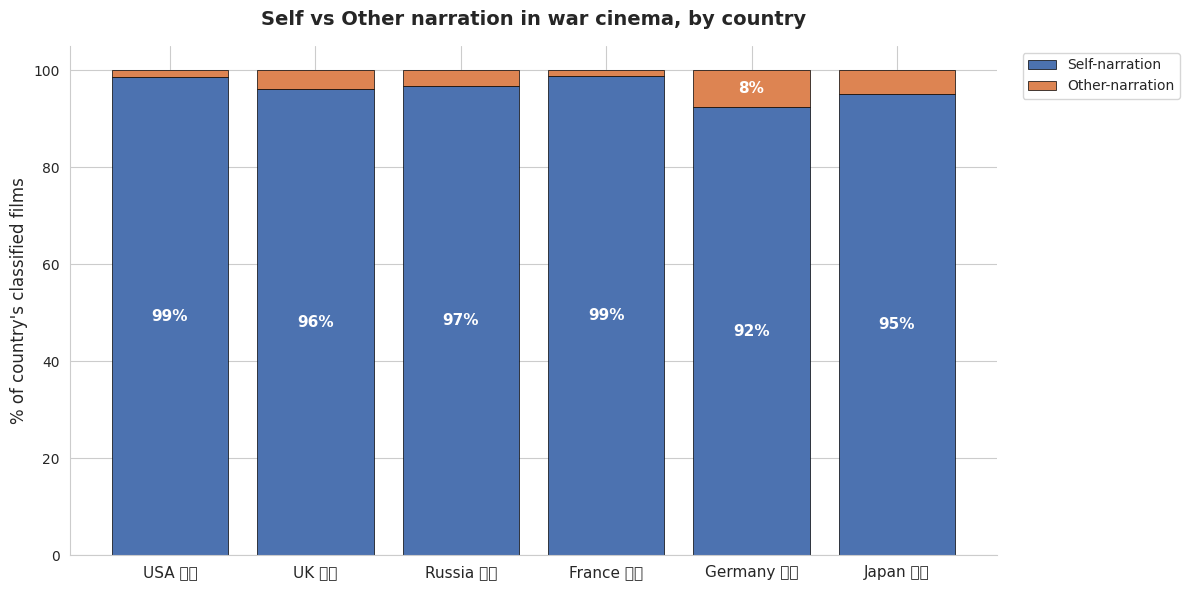

Self vs Other narration per country (%):
narration_type   other  self  unknown
primary_country                      
US                 1.4  98.6        0
GB                 3.9  96.1        0
RU                 3.4  96.6        0
FR                 1.2  98.8        0
DE                 7.6  92.4        0
JP                 4.8  95.2        0


In [7]:
narration_by_country = pd.crosstab(
    df_classified['primary_country'],
    df_classified['narration_type'],
    normalize='index'
) * 100

narration_by_country = narration_by_country.reindex(country_order)

for col in ['self', 'other', 'unknown']:
    if col not in narration_by_country.columns:
        narration_by_country[col] = 0

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(narration_by_country))
self_vals = narration_by_country['self'].values
other_vals = narration_by_country['other'].values

ax.bar(x, self_vals, color='#4C72B0', edgecolor='black', linewidth=0.5, label='Self-narration')
ax.bar(x, other_vals, bottom=self_vals, color='#DD8452', edgecolor='black', linewidth=0.5, label='Other-narration')

for i in range(len(narration_by_country)):
    ax.text(x[i], self_vals[i]/2, f"{self_vals[i]:.0f}%",
            ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    if other_vals[i] > 5:
        ax.text(x[i], self_vals[i] + other_vals[i]/2, f"{other_vals[i]:.0f}%",
                ha='center', va='center', fontsize=11, fontweight='bold', color='white')

ax.set_xticks(x)
ax.set_xticklabels([COUNTRY_NAMES[c] for c in narration_by_country.index], fontsize=11)
ax.set_ylabel("% of country's classified films", fontsize=12)
ax.set_title('Self vs Other narration in war cinema, by country',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, 105)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, fontsize=10)

plt.tight_layout()
plt.show()

print("Self vs Other narration per country (%):")
print(narration_by_country.round(1).to_string())

Films excluding WWII: 335 (out of 1445)


/tmp/ipykernel_15888/191018332.py:50: UserWarning:

Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_15888/191018332.py:50: UserWarning:

Glyph 127480 (\N{REGIONAL INDICATOR SYMBOL LETTER S}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_15888/191018332.py:50: UserWarning:

Glyph 127468 (\N{REGIONAL INDICATOR SYMBOL LETTER G}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_15888/191018332.py:50: UserWarning:

Glyph 127463 (\N{REGIONAL INDICATOR SYMBOL LETTER B}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_15888/191018332.py:50: UserWarning:

Glyph 127479 (\N{REGIONAL INDICATOR SYMBOL LETTER R}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_15888/191018332.py:50: UserWarning:

Glyph 127467 (\N{REGIONAL INDICATOR SYMBOL LETTER F}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_15888/191018332.py:50: UserWarning:

Glyph 127465 (\N{REGIONAL INDICATOR SYMBOL LETTER D}) missing from font(s) DejaVu Sans.

/tmp/ipykerne

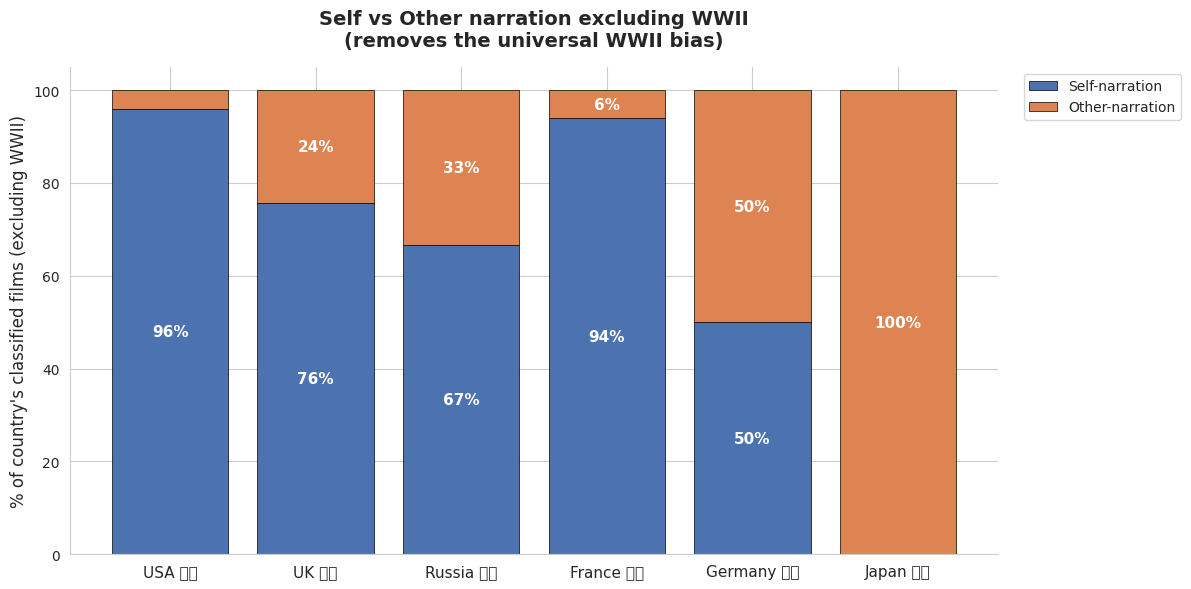

Self vs Other excluding WWII (%):
narration_type   other  self  unknown
primary_country                      
US                 4.1  95.9        0
GB                24.4  75.6        0
RU                33.3  66.7        0
FR                 6.1  93.9        0
DE                50.0  50.0        0
JP               100.0   0.0        0


In [8]:
# Re-run the analysis excluding WWII, which dominates every country and mechanically inflates self-narration rates

df_no_wwii = df_classified[df_classified['matched_conflict'] != 'World War II'].copy()

print(f"Films excluding WWII: {len(df_no_wwii)} (out of {len(df_classified)})")

# Recompute crosstab
narration_no_wwii = pd.crosstab(
    df_no_wwii['primary_country'],
    df_no_wwii['narration_type'],
    normalize='index'
) * 100

narration_no_wwii = narration_no_wwii.reindex(country_order)

for col in ['self', 'other', 'unknown']:
    if col not in narration_no_wwii.columns:
        narration_no_wwii[col] = 0

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(narration_no_wwii))
self_vals = narration_no_wwii['self'].values
other_vals = narration_no_wwii['other'].values

ax.bar(x, self_vals, color='#4C72B0', edgecolor='black', linewidth=0.5, label='Self-narration')
ax.bar(x, other_vals, bottom=self_vals, color='#DD8452', edgecolor='black', linewidth=0.5, label='Other-narration')

for i in range(len(narration_no_wwii)):
    if self_vals[i] > 5:
        ax.text(x[i], self_vals[i]/2, f"{self_vals[i]:.0f}%",
                ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    if other_vals[i] > 5:
        ax.text(x[i], self_vals[i] + other_vals[i]/2, f"{other_vals[i]:.0f}%",
                ha='center', va='center', fontsize=11, fontweight='bold', color='white')

ax.set_xticks(x)
ax.set_xticklabels([COUNTRY_NAMES[c] for c in narration_no_wwii.index], fontsize=11)
ax.set_ylabel("% of country's classified films (excluding WWII)", fontsize=12)
ax.set_title('Self vs Other narration excluding WWII\n(removes the universal WWII bias)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, 105)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, fontsize=10)

plt.subplots_adjust(right=0.85)
plt.tight_layout()
plt.show()

print("Self vs Other excluding WWII (%):")
print(narration_no_wwii.round(1).to_string())

In [9]:
print("Top 'other-narration' conflicts per country:")

for country in country_order:
    other_films = df_classified[
        (df_classified['primary_country'] == country) &
        (df_classified['narration_type'] == 'other')
    ]

    if len(other_films) == 0:
        print(f"\n{COUNTRY_NAMES[country]}: no 'other' conflicts")
        continue

    top_other = other_films['matched_conflict'].value_counts().head(5)
    print(f"\n{COUNTRY_NAMES[country]} ({len(other_films)} films filming others' conflicts):")
    for conflict, n in top_other.items():
        print(f"  - {conflict}: {n} films")

Top 'other-narration' conflicts per country:

USA 🇺🇸 (9 films filming others' conflicts):
  - Rwandan Genocide: 2 films
  - First Chechen War: 1 films
  - Northern Ireland Troubles: 1 films
  - Lebanese Civil War: 1 films
  - Mau Mau Uprising: 1 films

UK 🇬🇧 (10 films filming others' conflicts):
  - Vietnam War: 6 films
  - Berlin Wall: 1 films
  - Lebanese Civil War: 1 films
  - Hungarian Revolution: 1 films
  - Yom Kippur War: 1 films

Russia 🇷🇺 (7 films filming others' conflicts):
  - War in Afghanistan: 7 films

France 🇫🇷 (2 films filming others' conflicts):
  - Cold War: 1 films
  - Iraq War: 1 films

Germany 🇩🇪 (8 films filming others' conflicts):
  - Vietnam War: 2 films
  - Iraq War: 2 films
  - Gulf War: 1 films
  - Bosnian War: 1 films
  - Syrian Civil War: 1 films

Japan 🇯🇵 (3 films filming others' conflicts):
  - Vietnam War: 1 films
  - Korean War: 1 films
  - Bosnian War: 1 films


###Key insights

**At first glance: all national cinemas seem overwhelmingly self-centered**
(92–99% self-narration). But this result is **mechanically inflated by WWII**,
which involved all 6 countries and represents 66–95% of each country's
war cinema.

**Excluding WWII reveals three distinct patterns:**

**USA (95.9% self)** films Vietnam, Iraq, Afghanistan, Korea, the
Gulf War : every modern American war, told from an American perspective.
Hollywood's war cinema operates as a near-continuous chronicle of US
military engagements abroad, with the occasional foreign sidestep
(Rwanda, Northern Ireland) remaining marginal. This is the cinema of
a superpower telling its own military history to itself, decade after
decade : a tradition so consistent that "war film" and "American war
film" have nearly become synonyms in global pop culture.

**France (93.9% self)** is similarly anchored in its own military
past, but with a very different focus. French war cinema (outside WWII)
revolves around the **Algerian War** and the **First Indochina War**,
the painful colonial conflicts that the country needed decades to even
begin filming. Where the USA tells stories of military victories or
heroic failures, France tells stories of contested decolonization,
moral ambiguity, and post-imperial reckoning. Both cinemas are
self-centered, but they reveal opposite political traditions.

**UK (75.6% self / 24.4% other)** breaks from the self-centered
pattern, with one quarter of its non-WWII films treating foreign
conflicts. Strikingly, **6 of those 10 "other" films treat the Vietnam
War**, an American conflict the UK didn't participate in. This
reflects the deep cultural symbiosis between the British and American
film industries: British cinema regularly imports American narratives,
casts, and themes, producing what feels like a transatlantic dialogue.
The UK's "other" films (Berlin Wall, Yom Kippur War, Hungarian
Revolution) speak to its enduring post-imperial interest in global
events.

**Russia (66.7% self / 33.3% other)** has the highest "other"
rate after Germany. Strikingly, all 7 of its non-WWII "other" films
treat the **War in Afghanistan (2001–2021)**, the American-led
coalition war in which Russia did not participate. This is not
coincidence : Russia has a particular interest in the Afghan theater.
The country borders the Soviet sphere of influence, the USSR fought
its own decade-long Afghan war (1979–89), and Russian cinema has
revisited Afghanistan as both a geopolitical mirror and a contemporary
subject. Filming the American Afghan war allows Russian directors to
comment on Western military adventurism from a perspective shaped by
the USSR's own Afghan experience, an "echo cinema" that is a unique
signature of contemporary Russian war film.

**Germany (50/50)** is the most internationally-engaged war
cinema of the dataset, splitting its non-WWII output evenly between
its own military engagements (Bosnia, Kosovo, Afghanistan as part of
NATO operations) and foreign conflicts (Vietnam, Iraq, Gulf War,
Syria). This dual gaze is consistent with post-war Germany's distinct
posture : a country that, for historical reasons, has cultivated a
moral and cinematic stance of **looking outward**. Films about other
nations' wars become, indirectly, a way for German cinema to engage
with universal questions about militarism and intervention without
always centering Germany itself.

**Japan (0% self / 100% other outside WWII)** shows the most
striking result of all. Once WWII is removed, **none** of Japan's
remaining war films treat a conflict in which Japan was involved :  
all the three films address foreign wars (Vietnam, Korea, Bosnia). This
extreme pattern reflects Japan's post-1947 constitutional pacifism and the fact that, in over 75 years, Japan has had
virtually no military engagements to film. When Japanese war cinema
does step outside its national WWII memory, it does so as an
**observer**, not a participant. This posture is unique among the
6 countries.

⚠️ Statistical caveat : with only 3 such non-WWII films (out of 62
total Japanese films), the 100% figure is fragile. But it reinforces
a consistent picture across all our analyses : Japan's war cinema is
definitely concentrated on WWII.

**The big takeaway:**

> Removing WWII reveals what each cinema *chooses* to engage with
> beyond the universal reference. The USA and France inhabit their
> own military pasts in radically different ways : triumphal vs
> haunted. The UK extends its gaze toward its American cousin's wars.
> Russia films the American Afghan war as an echo of its own Soviet
> defeat. Germany alone looks broadly outward in a posture of
> deliberate post-war humility. And Japan, having limited its military
> role, concentrates its war cinema on WWII. And
> when it ventures elsewhere, it does so as an observer of
> conflicts that aren't its own.

In [10]:
# Classify each film into one of 3 temporal categories relative to its conflict

# Build start/end year lookups
conflict_start_years = conflicts.set_index('conflict')['start_year'].to_dict()
conflict_end_years = conflicts.set_index('conflict')['end_year'].to_dict()

def classify_temporal_position(row):
    """
    Classify the film's release timing relative to its matched conflict:
    - 'During': released while the conflict was active (or before it started, rare)
    - 'Aftermath': released within 10 years after the conflict ended
    - 'Long-term memory': released more than 10 years after the conflict ended
    """
    conflict = row['matched_conflict']
    release = row['release_year']

    if conflict not in conflict_end_years:
        return 'unknown'

    start = conflict_start_years[conflict]
    end = conflict_end_years[conflict]

    if release <= end:
        return 'During'
    elif release <= end + 10:
        return 'Aftermath'
    else:
        return 'Long-term memory'

df_classified['temporal_position'] = df_classified.apply(classify_temporal_position, axis=1)

# Overview
print("Temporal position breakdown:")
print(df_classified['temporal_position'].value_counts())

print("Percentages:")
print((df_classified['temporal_position'].value_counts(normalize=True) * 100).round(1))

Temporal position breakdown:
temporal_position
Long-term memory    1077
Aftermath            211
During               157
Name: count, dtype: int64
Percentages:
temporal_position
Long-term memory    74.5
Aftermath           14.6
During              10.9
Name: proportion, dtype: float64


/tmp/ipykernel_15888/2492803567.py:49: UserWarning:

Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_15888/2492803567.py:49: UserWarning:

Glyph 127480 (\N{REGIONAL INDICATOR SYMBOL LETTER S}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_15888/2492803567.py:49: UserWarning:

Glyph 127468 (\N{REGIONAL INDICATOR SYMBOL LETTER G}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_15888/2492803567.py:49: UserWarning:

Glyph 127463 (\N{REGIONAL INDICATOR SYMBOL LETTER B}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_15888/2492803567.py:49: UserWarning:

Glyph 127479 (\N{REGIONAL INDICATOR SYMBOL LETTER R}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_15888/2492803567.py:49: UserWarning:

Glyph 127467 (\N{REGIONAL INDICATOR SYMBOL LETTER F}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_15888/2492803567.py:49: UserWarning:

Glyph 127465 (\N{REGIONAL INDICATOR SYMBOL LETTER D}) missing from font(s) DejaVu Sans.

/tmp/i

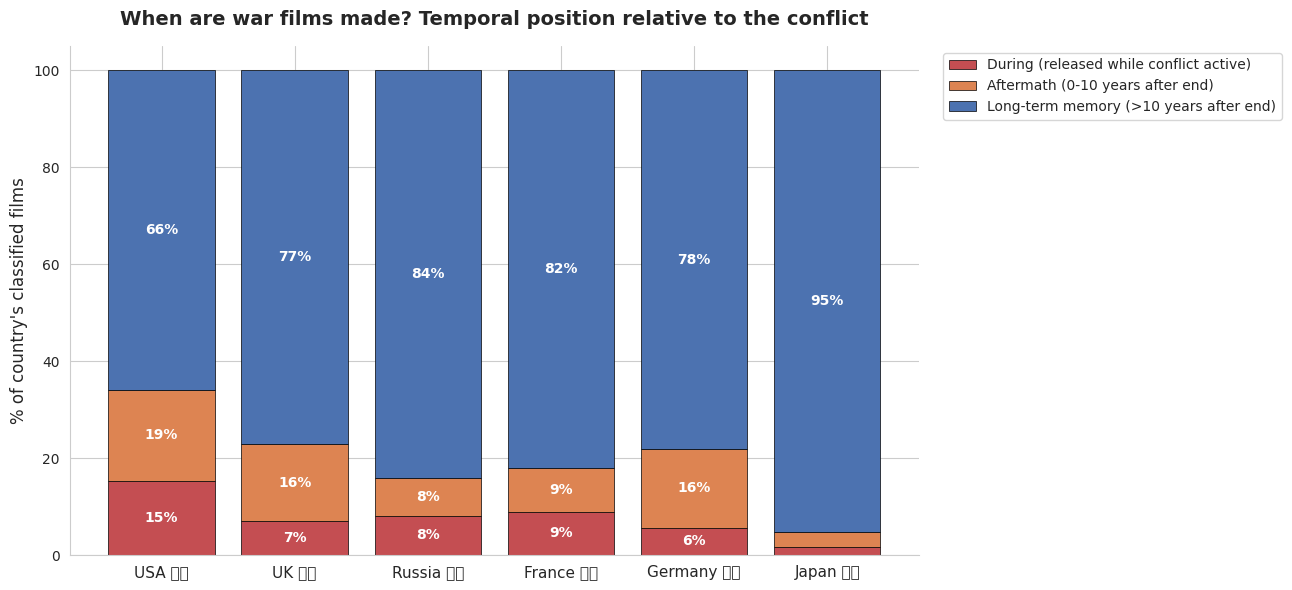

Temporal position per country (%):
temporal_position  During  Aftermath  Long-term memory
primary_country                                       
US                   15.4       18.6              65.9
GB                    7.1       15.7              77.2
RU                    8.2        7.7              84.1
FR                    9.0        9.0              82.0
DE                    5.7       16.2              78.1
JP                    1.6        3.2              95.2


In [11]:
# Stacked bar chart: how each country distributes its films across the 3 temporal positions
temporal_by_country = pd.crosstab(
    df_classified['primary_country'],
    df_classified['temporal_position'],
    normalize='index'
) * 100

# Reorder columns logically (chronological order of the 3 positions)
temporal_by_country = temporal_by_country.reindex(columns=['During', 'Aftermath', 'Long-term memory'], fill_value=0)
temporal_by_country = temporal_by_country.reindex(country_order)

# Build the stacked bar chart
fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(temporal_by_country))
during = temporal_by_country['During'].values
aftermath = temporal_by_country['Aftermath'].values
longterm = temporal_by_country['Long-term memory'].values

# Three colors that evoke a temporal gradient
ax.bar(x, during, color='#C44E52', edgecolor='black', linewidth=0.5, label='During (released while conflict active)')
ax.bar(x, aftermath, bottom=during, color='#DD8452', edgecolor='black', linewidth=0.5, label='Aftermath (0-10 years after end)')
ax.bar(x, longterm, bottom=during+aftermath, color='#4C72B0', edgecolor='black', linewidth=0.5, label='Long-term memory (>10 years after end)')

# Labels on each segment
for i in range(len(temporal_by_country)):
    if during[i] > 4:
        ax.text(x[i], during[i]/2, f"{during[i]:.0f}%",
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    if aftermath[i] > 4:
        ax.text(x[i], during[i] + aftermath[i]/2, f"{aftermath[i]:.0f}%",
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    if longterm[i] > 4:
        ax.text(x[i], during[i] + aftermath[i] + longterm[i]/2, f"{longterm[i]:.0f}%",
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')

ax.set_xticks(x)
ax.set_xticklabels([COUNTRY_NAMES[c] for c in temporal_by_country.index], fontsize=11)
ax.set_ylabel("% of country's classified films", fontsize=12)
ax.set_title('When are war films made? Temporal position relative to the conflict',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, 105)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, fontsize=10)

plt.subplots_adjust(right=0.7)
plt.tight_layout()
plt.show()

print("Temporal position per country (%):")
print(temporal_by_country.round(1).to_string())

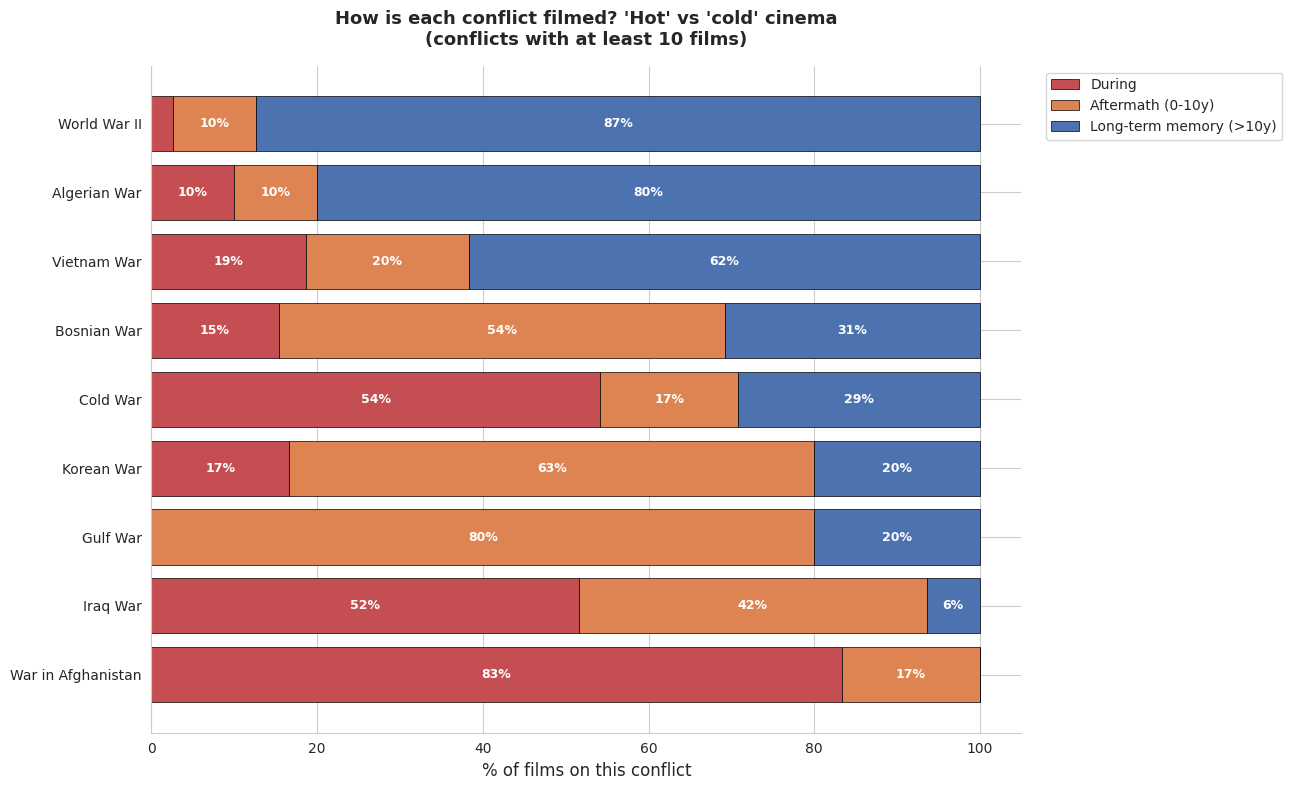

Temporal position per conflict (%):
temporal_position   During  Aftermath  Long-term memory
matched_conflict                                       
War in Afghanistan    83.3       16.7               0.0
Iraq War              51.6       41.9               6.5
Gulf War               0.0       80.0              20.0
Korean War            16.7       63.3              20.0
Cold War              54.2       16.7              29.2
Bosnian War           15.4       53.8              30.8
Vietnam War           18.7       19.6              61.7
Algerian War          10.0       10.0              80.0
World War II           2.6       10.0              87.4


In [12]:
# Same analysis but by conflict instead of by country
# This shows which conflicts are filmed "hot" vs "cold"

top_conflicts = df_classified['matched_conflict'].value_counts()
conflicts_to_plot = top_conflicts[top_conflicts >= 10].index.tolist()

df_plot = df_classified[df_classified['matched_conflict'].isin(conflicts_to_plot)].copy()

temporal_by_conflict = pd.crosstab(
    df_plot['matched_conflict'],
    df_plot['temporal_position'],
    normalize='index'
) * 100

temporal_by_conflict = temporal_by_conflict.reindex(columns=['During', 'Aftermath', 'Long-term memory'], fill_value=0)

# Sort by % of "Long-term memory" descending (most processed first)
temporal_by_conflict = temporal_by_conflict.sort_values('Long-term memory', ascending=True)

fig, ax = plt.subplots(figsize=(13, 8))

y = np.arange(len(temporal_by_conflict))
during = temporal_by_conflict['During'].values
aftermath = temporal_by_conflict['Aftermath'].values
longterm = temporal_by_conflict['Long-term memory'].values

ax.barh(y, during, color='#C44E52', edgecolor='black', linewidth=0.5, label='During')
ax.barh(y, aftermath, left=during, color='#DD8452', edgecolor='black', linewidth=0.5, label='Aftermath (0-10y)')
ax.barh(y, longterm, left=during+aftermath, color='#4C72B0', edgecolor='black', linewidth=0.5, label='Long-term memory (>10y)')

# Labels on segments
for i in range(len(temporal_by_conflict)):
    if during[i] > 5:
        ax.text(during[i]/2, y[i], f"{during[i]:.0f}%",
                ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    if aftermath[i] > 5:
        ax.text(during[i] + aftermath[i]/2, y[i], f"{aftermath[i]:.0f}%",
                ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    if longterm[i] > 5:
        ax.text(during[i] + aftermath[i] + longterm[i]/2, y[i], f"{longterm[i]:.0f}%",
                ha='center', va='center', fontsize=9, fontweight='bold', color='white')

ax.set_yticks(y)
ax.set_yticklabels(temporal_by_conflict.index, fontsize=10)
ax.set_xlabel("% of films on this conflict", fontsize=12)
ax.set_title("How is each conflict filmed? 'Hot' vs 'cold' cinema\n(conflicts with at least 10 films)",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, 105)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, fontsize=10)

plt.subplots_adjust(right=0.7)
plt.tight_layout()
plt.show()

print("Temporal position per conflict (%):")
print(temporal_by_conflict.round(1).to_string())

###Time-lag insights

**War cinema is overwhelmingly a cinema of memory.**

- **74.5% of all films** are released more than 10 years after the
  conflict ended ("Long-term memory")
- Only **10.9%** are filmed during the conflict itself
- The remaining 14.6% appear in the immediate aftermath (0-10 years)

This pattern reflects how war becomes cinematographically processable :
most countries need distance (sometimes decades) before they can
turn lived conflict into film.

**Country profiles diverge sharply:**

- **USA films "hot"** more than any other country (15.4% during +
  18.6% aftermath = 34% of films within 10 years of the conflict end).
  Hollywood operates as a near-real-time chronicler of American
  military engagements, with films like *American Sniper* (Iraq) or
  *12 Strong* (Afghanistan) appearing while wars were still ongoing.

- **Japan is the extreme opposite : 95.2% long-term memory.**
  Combined with its near-exclusive focus on WWII, this means Japanese
  war cinema is almost entirely a cinema of distant memory.

- **Russia (84.1% long-term)** echoes Japan's pattern : despite
  having recent conflicts (Chechen Wars, Afghanistan, Ukraine),
  Russian war cinema is overwhelmingly retrospective, dominated by
  the Great Patriotic War filmed from a distance.

- **Germany and 🇬🇧 UK** share a balanced profile, with notable
  shares in both "aftermath" (15-16%) and "long-term" (77-78%),
  suggesting a more even rhythm of cinematic processing.

**The most striking finding : conflicts are filmed on radically
different timelines.**

- **"Hot" conflicts (>50% filmed during the war)** :
  - War in Afghanistan (83.3%)
  - Cold War (54.2%)
  - Iraq War (51.6%)
  
  These are conflicts the cinema engaged with **in real time**.
  The Cold War's 47-year duration partly explains this : espionage
  films like Bond or Le Carré adaptations were Cold War cinema
  *during* the Cold War itself.

- **"Warm" conflicts (filmed mostly in the first 10 years after)** :
  - Gulf War (80% aftermath)
  - Korean War (63.3% aftermath)
  - Bosnian War (53.8% aftermath)
  
  These conflicts triggered an immediate post-war wave of films but
  didn't sustain long-term cinematic interest.

- **"Cold" conflicts (>60% long-term memory)** :
  - WWII (87.4%)
  - Algerian War (80%)
  - Vietnam War (61.7%)
  
  These required decades to be filmed at scale. The Algerian War is
  particularly telling : a French colonial conflict that took 60+ years
  for cinema to fully address, likely due to the painful nature of
  decolonization memory in France.

**The big takeaway:**

> War cinema operates on three timelines. **Real-time chronicle**
> (Afghanistan, Iraq, Cold War espionage), **immediate post-war
> processing** (Gulf War, Korea, Bosnia), and **long-term memory work**
> (WWII, Algeria, Vietnam).
>
> The longer a country needs to film a war, the more morally complex
> or politically charged that war likely was. Some wars are filmed
> while they happen, others have to wait a generation.

In [13]:
# For each conflict, I compute :
# - Number of distinct producing countries
# - Total number of films
# - Share of films from the dominant country (concentration index)

conflict_metrics = []

for conflict in df_classified['matched_conflict'].unique():
    subset = df_classified[df_classified['matched_conflict'] == conflict]

    n_countries = subset['primary_country'].nunique()
    n_films = len(subset)

    # Concentration : % of films from the country that filmed it the most
    country_counts = subset['primary_country'].value_counts()
    dominant_share = (country_counts.iloc[0] / n_films) * 100
    dominant_country = country_counts.index[0]

    conflict_metrics.append({
        'conflict': conflict,
        'n_countries': n_countries,
        'n_films': n_films,
        'dominant_country': dominant_country,
        'dominant_share': dominant_share
    })

metrics_df = pd.DataFrame(conflict_metrics)

# Sort by number of countries first, then by total films
metrics_df = metrics_df.sort_values(['n_countries', 'n_films'], ascending=[False, False]).reset_index(drop=True)

print("Conflict universality metrics:\n")
print(metrics_df.to_string(index=False))

Conflict universality metrics:

                 conflict  n_countries  n_films dominant_country  dominant_share
             World War II            6     1110               US       38.558559
              Vietnam War            5      107               US       85.046729
       War in Afghanistan            5       60               US       63.333333
                 Cold War            5       24               US       45.833333
              Bosnian War            5       13               US       30.769231
                 Iraq War            4       31               US       74.193548
               Korean War            3       30               US       90.000000
                 Gulf War            3       10               US       80.000000
      Russo-Ukrainian War            3        6               US       50.000000
         Syrian Civil War            3        5               GB       40.000000
             Algerian War            2       10               FR       90.000

In [14]:
# I Classify conflicts into 3 categories based on the number of producing countries

def classify_universality(n_countries):
    if n_countries >= 5:
        return 'Universal (5-6 countries)'
    elif n_countries >= 2:
        return 'Shared (2-4 countries)'
    else:
        return 'National (1 country)'

metrics_df['universality'] = metrics_df['n_countries'].apply(classify_universality)

# Counts and percentages
print("Conflict distribution by universality:")
print(metrics_df['universality'].value_counts())

print("Examples in each category:\n")
for cat in ['Universal (5-6 countries)', 'Shared (2-4 countries)', 'National (1 country)']:
    print(f"\n--- {cat} ---")
    subset = metrics_df[metrics_df['universality'] == cat]
    for _, row in subset.iterrows():
        print(f"  {row['conflict']}: {row['n_films']} films across {row['n_countries']} countries (dominant: {row['dominant_country']} at {row['dominant_share']:.0f}%)")

Conflict distribution by universality:
universality
Shared (2-4 countries)       15
National (1 country)          6
Universal (5-6 countries)     5
Name: count, dtype: int64
Examples in each category:


--- Universal (5-6 countries) ---
  World War II: 1110 films across 6 countries (dominant: US at 39%)
  Vietnam War: 107 films across 5 countries (dominant: US at 85%)
  War in Afghanistan: 60 films across 5 countries (dominant: US at 63%)
  Cold War: 24 films across 5 countries (dominant: US at 46%)
  Bosnian War: 13 films across 5 countries (dominant: US at 31%)

--- Shared (2-4 countries) ---
  Iraq War: 31 films across 4 countries (dominant: US at 74%)
  Korean War: 30 films across 3 countries (dominant: US at 90%)
  Gulf War: 10 films across 3 countries (dominant: US at 80%)
  Russo-Ukrainian War: 6 films across 3 countries (dominant: US at 50%)
  Syrian Civil War: 5 films across 3 countries (dominant: GB at 40%)
  Algerian War: 10 films across 2 countries (dominant: FR at 90%)
  F

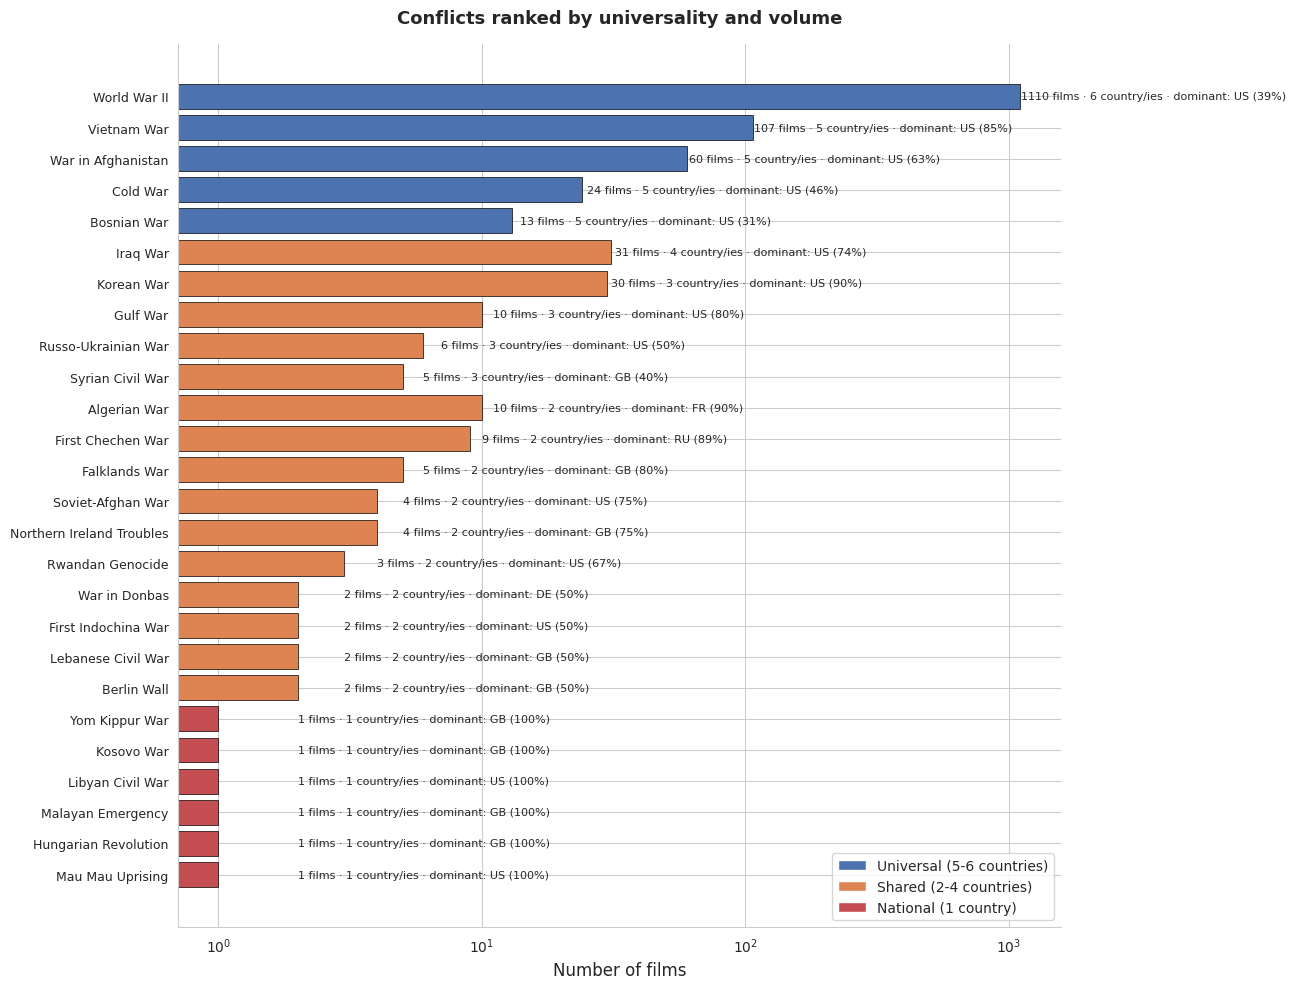

In [22]:
# Horizontal bar chart showing all conflicts, grouped by universality
# Sorted within each group by film count

fig, ax = plt.subplots(figsize=(13, 10))

# Sort all conflicts by universality then by film count
display_order = metrics_df.sort_values(
    ['n_countries', 'n_films'],
    ascending=[True, True]
).reset_index(drop=True)

y_positions = np.arange(len(display_order))
colors = [universality_colors[u] for u in display_order['universality']]

bars = ax.barh(y_positions, display_order['n_films'], color=colors, edgecolor='black', linewidth=0.5)

# Add labels with country count
for i, row in display_order.iterrows():
    ax.text(
        row['n_films'] + 1,
        i,
        f"{row['n_films']} films · {row['n_countries']} country/ies · dominant: {row['dominant_country']} ({row['dominant_share']:.0f}%)",
        va='center',
        fontsize=8
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(display_order['conflict'], fontsize=9)
ax.set_xlabel('Number of films', fontsize=12)
ax.set_title('Conflicts ranked by universality and volume',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xscale('log')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=universality_colors[u], label=u)
    for u in ['Universal (5-6 countries)', 'Shared (2-4 countries)', 'National (1 country)']
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True, fontsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

###Universality insights

**Most conflicts remain national or sub-regional cinematic subjects.**

Of the 26 conflicts in our dataset :
- Only **5 conflicts (19%) are universally filmed** by 5-6 countries
- 15 conflicts (58%) are shared by 2-4 countries
- 6 conflicts (23%) are filmed by a single country

**WWII is the only truly universal conflict.**

WWII alone is filmed by all 6 countries, with relatively balanced
contributions (US 39%, others 7-19%). It is the **only conflict** in
our dataset that genuinely transcends national borders : every country
in our sample has built its own cinematic relationship with this war.

**The other "universal" conflicts are American hegemonies in disguise.**

Vietnam War, War in Afghanistan, Cold War, and Bosnian War are
technically filmed by 5 countries, but the production is heavily
US-dominated :
- Vietnam War : 85% American films
- War in Afghanistan : 63% American  
- Cold War : 46% American

What looks "universal" is often "American with token participation
from other countries". Hollywood's cultural reach is so wide that
when a conflict involves the US, films appear globally, but **led
by US production**.

**True national signatures : 4 conflicts dominated by a single
non-American country.**

These are the cinematic "property" of one nation:
- **Algerian War**: 90% French. France has near-exclusive
  ownership of this colonial memory
- **First Chechen War**: 89% Russian. Only Russia has chosen
  to film this brutal post-Soviet conflict
- **Falklands War**: 80% British. The South Atlantic conflict
  remains an explicitly British subject
- **Northern Ireland Troubles**: 75% British. Also a British
  specialty, with limited foreign interest

**Telling silences :**

- The **Mau Mau Uprising** (Kenya, 1952-60), a British colonial
  conflict, is filmed only **by the USA** (a single film), never
  by the UK itself. This represents a clear blind spot in British
  cinema on its own colonial history.

- The **Malayan Emergency** and **Hungarian Revolution** each have
  only one film (UK), highlighting how marginal these mid-20th-century
  events have become cinematically.

- **6 conflicts** (Mau Mau, Hungarian, Malayan, Libyan, Kosovo,
  Yom Kippur) appear only once in our entire dataset. They are
  cinematically "frozen" : barely processed by any national cinema.

**A surprising case : Soviet-Afghan War, filmed more by Americans
than by Russians.**

The 1979-89 Soviet invasion of Afghanistan generated 4 films in our
dataset : 3 American (*Rambo III*, *The Beast*, and *Afgan : The Soviet
Experience*) and 1 Russian (*Peshawar Waltz*). Hollywood has thus
engaged more with the Soviet Afghan war than Russian cinema itself,  
a reversal that reflects the Cold War framing of this conflict as a
US-perspective story (mujahideen as freedom fighters, Soviet defeat
as Cold War triumph).

**The big takeaway :**

> Despite the appearance of universality, war cinema is a
> **fragmented landscape**. Only WWII speaks across all six
> countries as a shared cinematic language. The other "universal"
> conflicts are American-dominated narratives that other countries
> occasionally contribute to. Beyond that, each country guards its
> own conflicts : France owns Algeria, Russia owns Chechnya, the UK
> owns the Falklands. And many wars (especially colonial conflicts)
> remain cinematically untold, even by the countries that fought
> them.